# DDPM
拡散モデル

## import

In [47]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


## Use GPU if Available

In [48]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


## U-Net
スキップ接続を利用して大域的な特徴と局所的な特徴の両方を捉える，畳み込みニューラルネットワーク．入出力次元が一致する．

In [49]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.convs(x)

class UNet(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()

        self.down1 = ConvBlock(in_ch, 64)
        self.down2 = ConvBlock(64, 128)
        self.bot1 = ConvBlock(128, 256)
        self.up2 = ConvBlock(128 + 256, 128)
        self.up1 = ConvBlock(64 + 128, 64)
        self.out = nn.Conv2d(64, in_ch, kernel_size=1) # シンプルな特徴マップの重み付き和

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x):
        x1 = self.down1(x)
        x = self.maxpool(x1)
        x2 = self.down2(x)
        x = self.maxpool(x2)

        x = self.bot1(x)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1) # チャネル次元で結合
        x = self.up2(x)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1) # チェネル次元で結合
        x = self.up1(x)

        x = self.out(x)

        return x

model = UNet()
x = torch.randn(10, 1, 28, 28) # dummy input
y = model(x)
print(y.shape)

if x.shape == y.shape:
    print("入出力次元が一致している．")
else:
    print("入出力次元が一致していない．")


torch.Size([10, 1, 28, 28])
入出力次元が一致している．


## Sinusoidal Position Encoding
正弦波位置エンコーディング

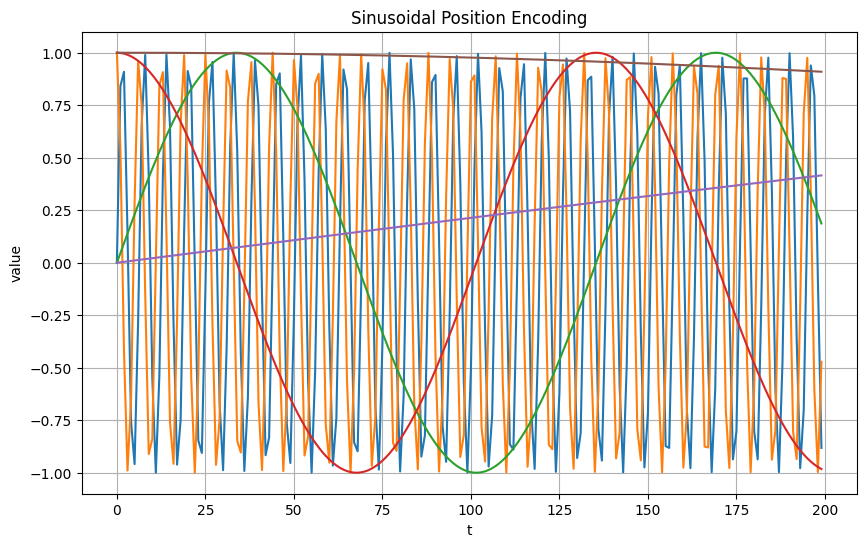

In [50]:
D = 6
T = 200

t = np.arange(T)

V = np.zeros((T, D))

for k in range(0, D, 2):

    scale = 10000 ** (k / D)

    V[:, k]   = np.sin(t / scale)
    V[:, k+1] = np.cos(t / scale)

plt.figure(figsize=(10, 6))

for i in range(D):
    plt.plot(t, V[:, i])

plt.xlabel("t")
plt.ylabel("value")
plt.title("Sinusoidal Position Encoding")
plt.grid()
plt.show()


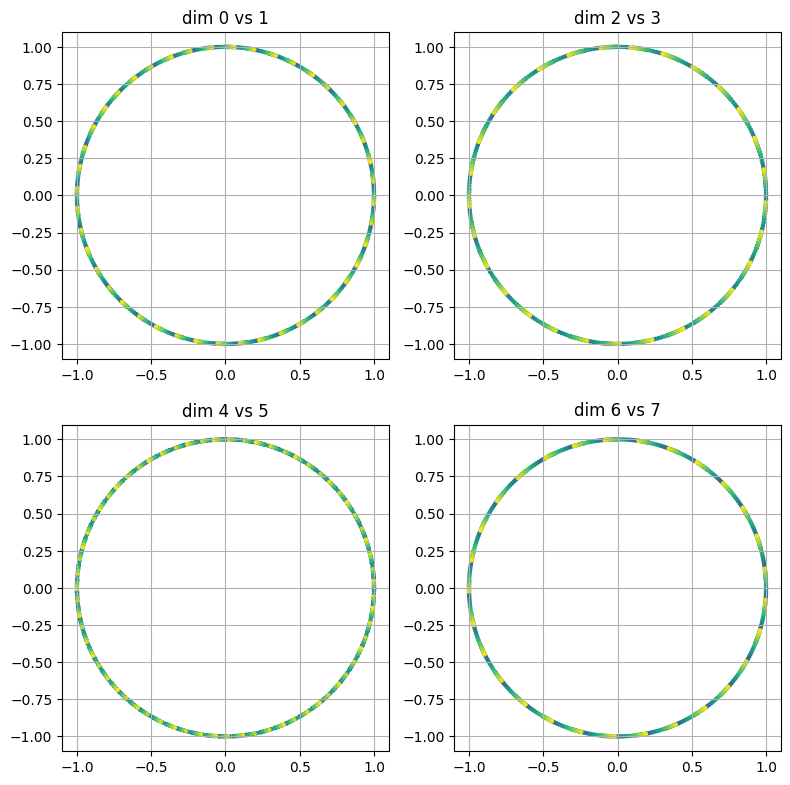

In [51]:
"""
違うのは，
- 円の形ではなく
- 円を回る速度
です．
"""

D = 128
T = 512

t = np.arange(T)

V = np.zeros((T, D))

for k in range(0, D, 2):
    scale = 10000 ** (k / D)

    V[:, k]   = np.sin(t / scale)
    V[:, k+1] = np.cos(t / scale)

# ------------------------
# 円を表示
# ------------------------

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

pairs = [0, 2, 4, 6]

for ax, k in zip(axes.ravel(), pairs):

    ax.scatter(
        V[:, k],
        V[:, k+1],
        c=t,
        s=5,
    )

    ax.set_title(f"dim {k} vs {k+1}")
    ax.set_aspect("equal")
    ax.grid()

plt.tight_layout()
plt.show()


positional_encoding.gif を保存しました！


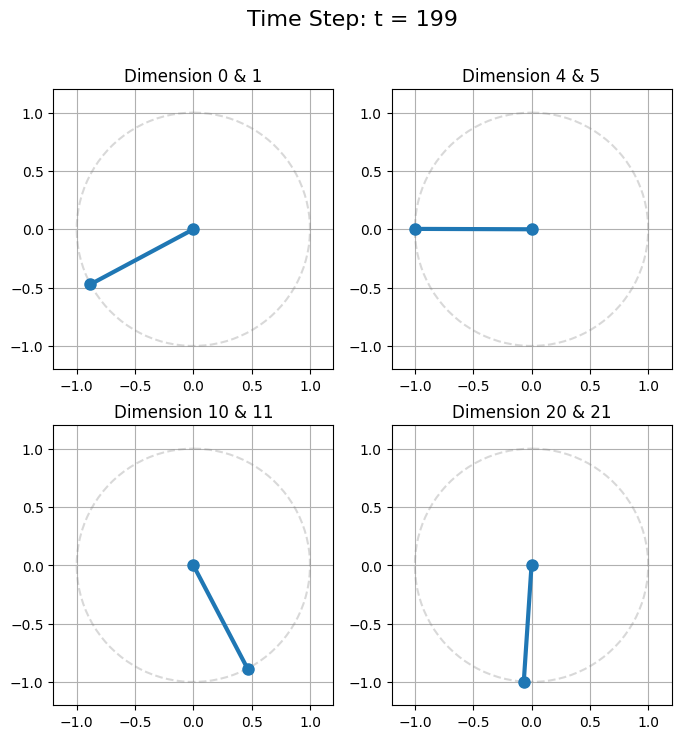

In [ ]:
"""
「高次元（大きいインデックス）の情報を参照する＝時計の時針を見るように，ゆったりとした時間の流れ（大局的な位置）を確認している」という，
Transformerや拡散モデルの気持ちが視覚化される．
"""

D = 128
T = 200  # GIFが長くなりすぎないように200ステップ
t_vals = np.arange(T)

# データの事前計算（論文に忠実に、ペアで同じスケールを共有）
V = np.zeros((T, D))
for k in range(0, D, 2):
    scale = 10000 ** (k / D)
    V[:, k]   = np.sin(t_vals / scale)
    V[:, k+1] = np.cos(t_vals / scale)

# 描画のセットアップ
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
# 少し差が分かりやすいように、kのステップを飛ばして抽出
pairs = [0, 4, 10, 20] 
lines = []

# 背景の円と、針（Line2D）の初期化
theta = np.linspace(0, 2*np.pi, 100)
for ax, k in zip(axes.ravel(), pairs):
    # 背景の補助線（単位円）
    ax.plot(np.sin(theta), np.cos(theta), color='gray', linestyle='--', alpha=0.3)
    
    # 針のオブジェクト（初期は空）
    line, = ax.plot([], [], 'o-', lw=3, markersize=8)
    lines.append(line)
    
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f"Dimension {k} & {k+1}")
    ax.set_aspect("equal")
    ax.grid(True)

# アニメーションの初期化関数
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# 各フレーム（時刻 t）での更新処理
def update(frame):
    t = t_vals[frame]
    fig.suptitle(f"Time Step: t = {t}", fontsize=16)
    
    for i, k in enumerate(pairs):
        x = V[frame, k]     # sin (x座標)
        y = V[frame, k+1]   # cos (y座標)
        
        # 原点(0,0)から(x,y)へ線を引く
        lines[i].set_data([0, x], [0, y])
        
    return lines

# アニメーションの作成 (interval=50 は 50ミリ秒ごとに更新)
ani = FuncAnimation(fig, update, frames=T, init_func=init, blit=False, interval=50)

# GIFとして保存 (※Pillowがインストールされている必要があります: pip install Pillow)
ani.save("positional_encoding.gif", writer="pillow", fps=20)
print("positional_encoding.gif を保存しました！")

plt.show()


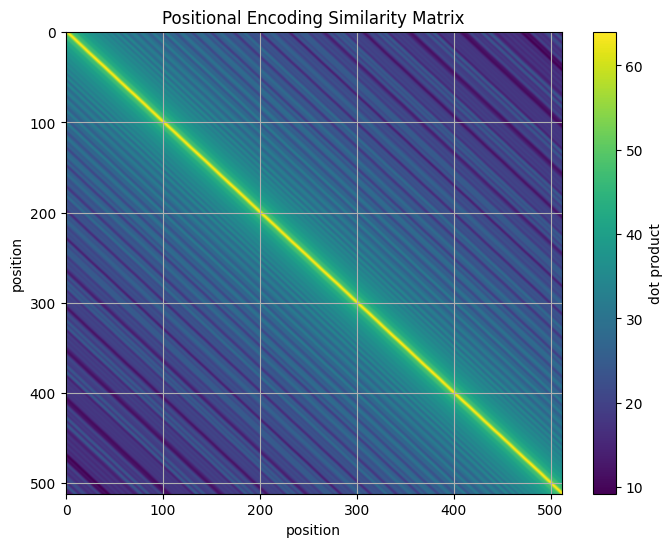

In [53]:
"""
時刻iのベクトルと，時刻jのベクトルの内積（類似度）を総当たりで計算している．
対角成分が明るいのは，i=jの場合の内積をとっているから当たり前．
iとjの差が大きくなるほど，だんだんと内積が小さくなっていく．
対角成分と平行に，なんらかの模様が走っている．
これは「類似度が，絶対的な時刻ではなく，2つの時刻の相対的な距離だけで決まっている．」事を示唆している．
"""

D = 128
T = 512

t = np.arange(T)

V = np.zeros((T, D))

for k in range(0, D, 2):
    scale = 10000 ** (k / D)

    V[:, k]   = np.sin(t / scale)
    V[:, k+1] = np.cos(t / scale)

# 類似度行列
S = V @ V.T

plt.figure(figsize=(8, 6))
plt.imshow(S, aspect="auto")
plt.colorbar(label="dot product")
plt.xlabel("position")
plt.ylabel("position")
plt.title("Positional Encoding Similarity Matrix")
plt.grid()
plt.show()
